In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
pd.options.display.float_format = '{:.5f}'.format
pd.options.display.max_columns = None

from datetime import datetime, date
from dateutil.relativedelta import relativedelta
import time
import random

import yfinance as yf
import requests
from fredapi import Fred

from statsmodels.tsa.seasonal import STL
from sktime.utils.plotting import plot_correlations
from scipy.stats import randint, uniform, loguniform
from scipy.special import boxcox, inv_boxcox

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.rcParams['figure.figsize'] = (18, 9)
plt.rcParams["figure.autolayout"] = True

from get_data import DataMaker  # самодельная библиотека для сбора датасетов
from ml_models import *

from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, make_scorer, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Если вы используете absl-логгер (TensorFlow внутри абстрагируется через absl):
from absl import logging as absl_logging
absl_logging.set_verbosity(absl_logging.ERROR)
absl_logging.set_stderrthreshold('ERROR')
absl_logging.use_absl_handler()

# Окончательно для Python-логгера TensorFlow
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM, GRU, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore')

2025-05-07 23:03:30.517969: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746648210.545741   39741 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746648210.554145   39741 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-07 23:03:30.583533: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# dm = DataMaker(
#     start_date='2018-01-01',
#     end_date=date.today(),
#     fred_api_key='6a6f2223ac49bf0fbb489f73a509bb18'
# )

# minute = dm.build_minute_dataset()
# hour = dm.build_hourly_dataset()

# day = dm.build_daily_dataset()
# week = dm.build_weekly_dataset()

In [3]:
# minute.to_csv('minute_df.csv')
# hour.to_csv('hour_df.csv')
# day.to_csv('day_df.csv')
# week.to_csv('week_df.csv')

In [4]:
# day.BTC.plot(label='BTC')
# # day.BTC.rolling(20).mean().plot(label='ma(20)')
# # day.BTC.shift(20).iloc[20:].plot(label='y[t-20]');
# day.BTC.shift(5).iloc[5:].plot(label='y[t-20]');

# print('ma(5) corr: ',
#     np.corrcoef(
#         day.BTC.iloc[5:],
#         day.BTC.rolling(5).mean().iloc[5:]
#     )[0][1]
# )

# print('ma(10) corr: ',
#     np.corrcoef(
#         day.BTC.iloc[10:],
#         day.BTC.rolling(10).mean().iloc[10:]
#     )[0][1]
# )

# print('lag 5 corr: ',
#     np.corrcoef(
#         day.BTC.iloc[5:],
#         day.BTC.shift(5).iloc[5:]
#     )[0][1]
# )

# print('lag 20 corr: ',
#     np.corrcoef(
#         day.BTC.iloc[20:],
#         day.BTC.shift(20).iloc[20:]
#     )[0][1]
# )

# plt.legend();

In [5]:
day=pd.read_csv('day_df.csv', parse_dates=['Date'], index_col=['Date'])

In [6]:
day.columns

Index(['BTC', 'Apple', 'Cardano', 'Adobe', 'AMD', 'Amazon', 'ARKK_ETF',
       'ARK_NextGen_Internet_ETF', 'AUD/USD', 'Bitcoin_Cash', 'Brent_Oil',
       'USD/CHF', 'WTI', 'Dogecoin', 'Ethereum_Classic', 'ETH', 'EUR/USD',
       'GBP/USD', 'Gold', 'Google', 'Copper', 'Intel', 'USD/JPY', 'Chainlink',
       'Litecoin', 'Marathon_Digital', 'Meta', 'Microsoft', 'MicroStrategy',
       'Natural_Gas', 'NVIDIA', 'Platinum', 'Invesco_QQQ', 'Riot_Blockchain',
       'Silver', 'VanEck_Semiconductor_ETF', 'iShares_Semiconductor_ETF',
       'TRON', 'Tesla', 'USD/CAD', 'Tether', 'SPDR_Materials', 'SPDR_Energy',
       'SPDR_Financials', 'SPDR_Industrials', 'SPDR_Tech', 'Stellar',
       'SPDR_RealEstate', 'SPDR_HealthCare', 'SPDR_Consumer_Discretionary',
       'XRP', 'Dow_Jones', 'S&P_500', 'NASDAQ_100', 'VIX', 'RSI', 'MACD',
       'ATR', 'OBV', 'Unemployment_Rate', 'Non_Farm_Payrolls',
       'Initial_Jobless_Claims', 'CPI', 'PCE_Price_Index',
       'Consumer_Confidence_Index', 'Retail_Sales'

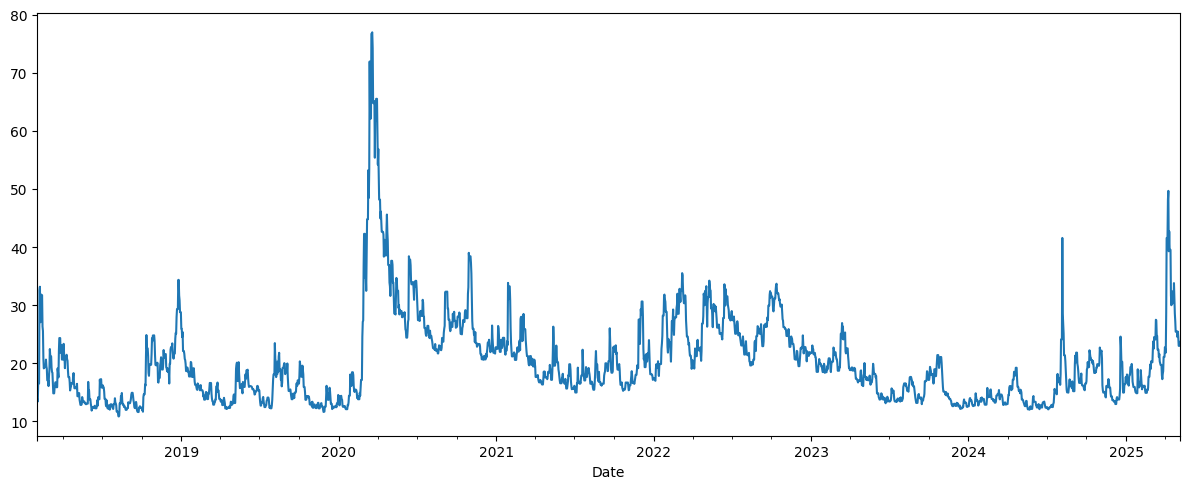

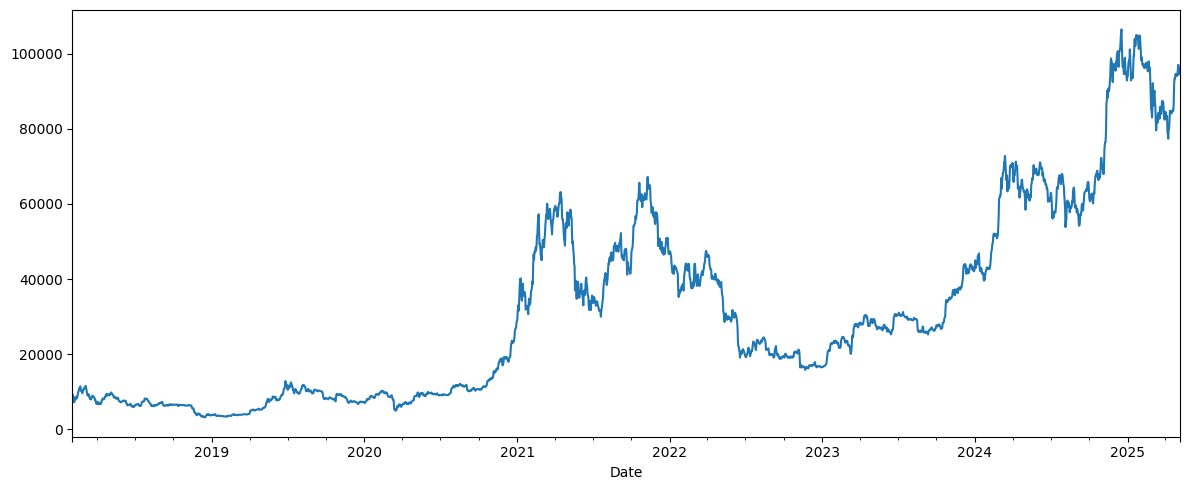

In [7]:
plt.figure(figsize=(12, 5))

day[['VIX', 'RSI', 'MACD',
       'ATR', 'OBV']].iloc[:, 0].plot()

plt.figure(figsize=(12, 5))
day.BTC.plot();

In [8]:
df = day.drop(columns=[
                'BTC_lag1', 
                'BTC_lag2', 
                'BTC_lag5', 
                'BTC_lag10', 
                'BTC_mean5', 
                # 'BTC_std10'
        ])

X = df.drop(columns=['BTC'])
y = df['BTC']

In [9]:
rf = StackingForecaster(
    test_size=216
)
rf.fit(X, y)


[2025-05-07 23:03:34] Начало RandomForest стек


E0000 00:00:1746648217.963388   39792 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746648217.969804   39792 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1746648218.049819   39793 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746648218.058185   39793 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1746648218.147334   39796 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746648218.148380   39789 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factor


[2025-05-07 23:15:16] Finished RandomForest training


StackingForecaster(test_size=216)

In [10]:
# catboost = StackingForecaster(
#     test_size=216,
#     model_type='CatBoost'
# )
# catboost.fit(X, y)

In [11]:
xgboost = StackingForecaster(
    test_size=216,
    model_type='XGBoost'
)
xgboost.fit(X, y)


[2025-05-07 23:15:17] Начало XGBoost стек


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
lgbm = StackingForecaster(
    test_size=216,
    model_type='LightGBM'
)
lgbm.fit(X, y)


[2025-05-07 20:59:01] Начало LightGBM стек


E0000 00:00:1746640745.237015   34555 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746640745.244551   34555 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1746640745.679723   34609 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746640745.688820   34609 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1746640749.054602   34846 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746640749.068171   34846 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register fact


[2025-05-07 21:01:45] Finished LightGBM training


StackingForecaster(model_type='LightGBM', test_size=216)

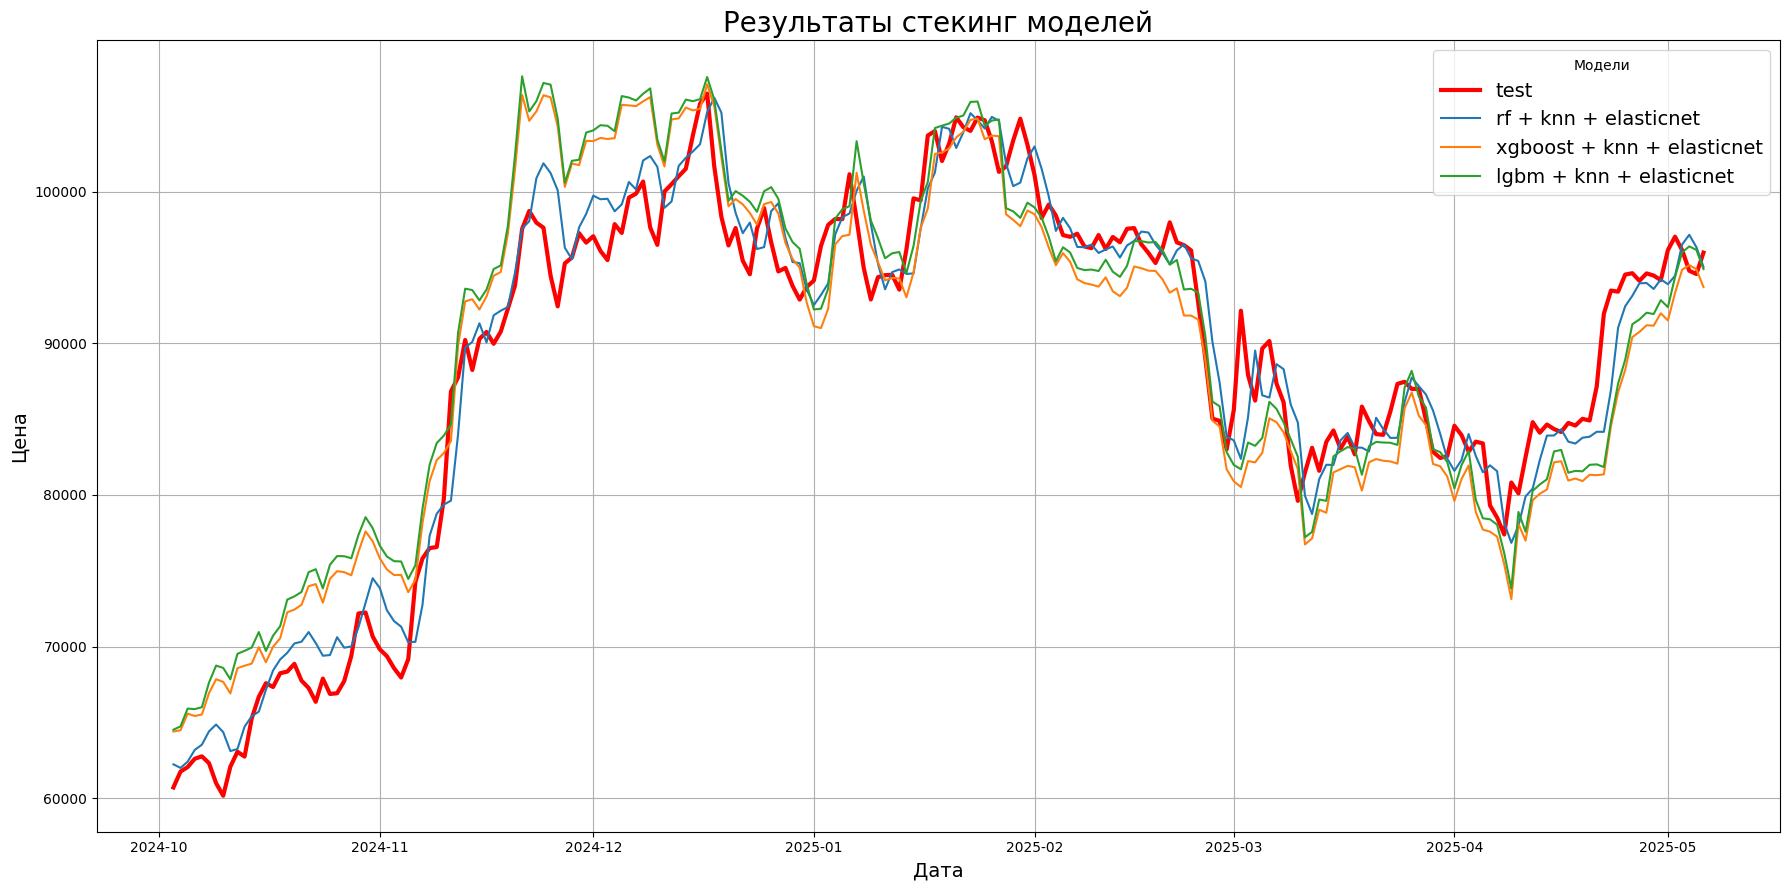

In [ ]:
plt.plot(
    y.iloc[-216:], label='test', c='red', linewidth=3
)
plt.plot(
    rf.result_.y_pred, label='rf + knn + elasticnet'
)
# plt.plot(
#     catboost.result_.y_pred, label='catboost + knn + elasticnet'
# )
plt.plot(
    xgboost.result_.y_pred, label='xgboost + knn + elasticnet'
)
plt.plot(
    lgbm.result_.y_pred, label='lgbm + knn + elasticnet'
)
plt.title('Результаты стекинг моделей', fontsize=20)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена', fontsize=14)

plt.legend(title='Модели', fontsize=14)
plt.grid(True)


In [ ]:
stack_results = pd.DataFrame({
    'rf train': rf.result_.metrics['train'].values(),
    # 'catboost train': catboost.result_.metrics['train'].values(),
    'xgboost train': xgboost.result_.metrics['train'].values(),
    'lgbm train': lgbm.result_.metrics['train'].values(),

    'rf test': rf.result_.metrics['test'].values(),
    # 'catboost test': catboost.result_.metrics['test'].values(),
    'xgboost test': xgboost.result_.metrics['test'].values(),
    'lgbm test': lgbm.result_.metrics['test'].values(),
},
index=rf.result_.metrics['train'].keys())

stack_results

,rf train,xgboost train,lgbm train,rf test,xgboost test,lgbm test
mae,907.58518,1712.23707,2063.32495,2008.00758,3678.66750,3641.42296
rmse,1356.85970,2272.36376,2659.85380,2619.95724,4399.98883,4506.15288
smape,0.04393,0.09451,0.11895,0.02307,0.04280,0.04243
mase,1.80913,3.41309,4.11293,4.00266,7.33287,7.25862


In [24]:
df_lin = day.drop(columns=[
                'BTC_lag1', 
                'BTC_lag2', 
                'BTC_lag5', 
                'BTC_lag10', 
                'BTC_mean5', 
                # 'BTC_std10',
                # 'RSI', 
                # 'MACD', 
                # 'ATR', 
                # 'OBV'
        ])

X_lin = df_lin.drop(columns=['BTC'])
y_lin = df_lin['BTC']

lasso = LinearForecaster(test_size=216, cv_splits=3, model_type='Lasso')
lasso.fit(X_lin, y_lin)

ridge = LinearForecaster(test_size=216, cv_splits=3, model_type='Ridge')
ridge.fit(X_lin, y_lin)

elastic = LinearForecaster(test_size=216, cv_splits=3, model_type='ElasticNet')
elastic.fit(X_lin, y_lin)


[2025-05-07 22:01:35] Starting Lasso training


E0000 00:00:1746644497.799181   37405 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746644497.805441   37405 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1746644498.126787   37408 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746644498.133086   37408 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1746644498.176496   37414 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746644498.182646   37414 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register fact


[2025-05-07 22:01:43] Finished Lasso training

[2025-05-07 22:01:43] Starting Ridge training

[2025-05-07 22:01:45] Finished Ridge training


LinearForecaster(cv_splits=3, test_size=216)

In [21]:
X_lin.columns

Index(['Apple', 'Cardano', 'Adobe', 'AMD', 'Amazon', 'ARKK_ETF',
       'ARK_NextGen_Internet_ETF', 'AUD/USD', 'Bitcoin_Cash', 'Brent_Oil',
       'USD/CHF', 'WTI', 'Dogecoin', 'Ethereum_Classic', 'ETH', 'EUR/USD',
       'GBP/USD', 'Gold', 'Google', 'Copper', 'Intel', 'USD/JPY', 'Chainlink',
       'Litecoin', 'Marathon_Digital', 'Meta', 'Microsoft', 'MicroStrategy',
       'Natural_Gas', 'NVIDIA', 'Platinum', 'Invesco_QQQ', 'Riot_Blockchain',
       'Silver', 'VanEck_Semiconductor_ETF', 'iShares_Semiconductor_ETF',
       'TRON', 'Tesla', 'USD/CAD', 'Tether', 'SPDR_Materials', 'SPDR_Energy',
       'SPDR_Financials', 'SPDR_Industrials', 'SPDR_Tech', 'Stellar',
       'SPDR_RealEstate', 'SPDR_HealthCare', 'SPDR_Consumer_Discretionary',
       'XRP', 'Dow_Jones', 'S&P_500', 'NASDAQ_100', 'VIX', 'RSI', 'MACD',
       'ATR', 'OBV', 'Unemployment_Rate', 'Non_Farm_Payrolls',
       'Initial_Jobless_Claims', 'CPI', 'PCE_Price_Index',
       'Consumer_Confidence_Index', 'Retail_Sales', 'Hous

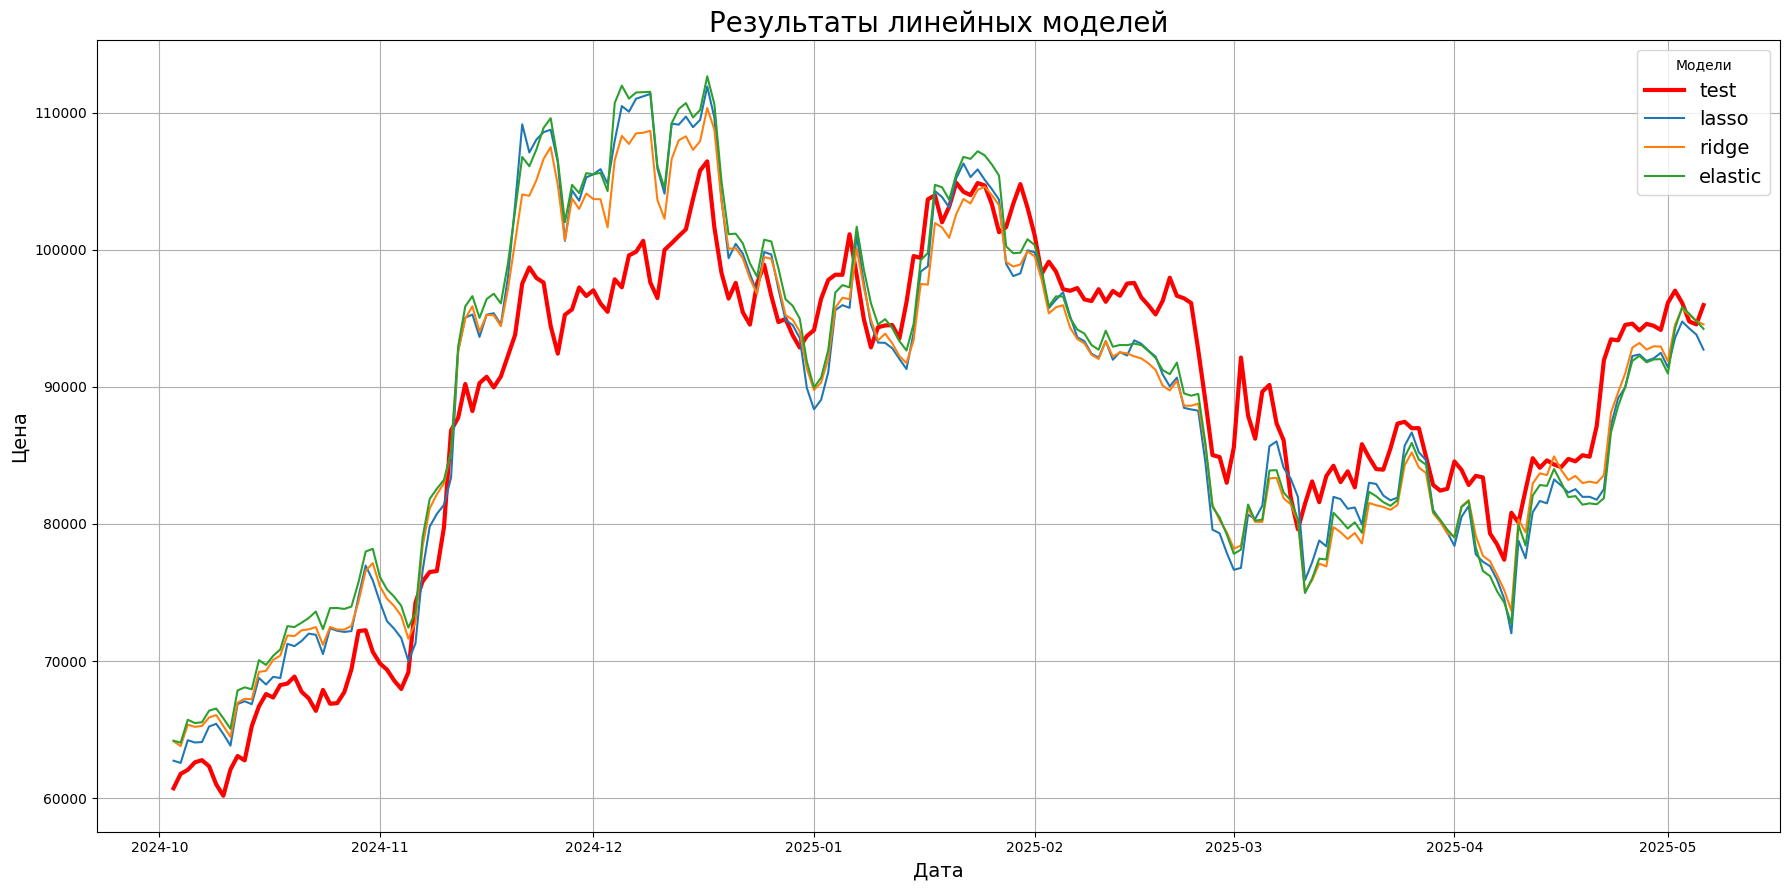

In [25]:

plt.plot(y_lin.iloc[-216:], label='test', c='red', linewidth=3)
plt.plot(lasso.result_.y_pred, label='lasso') 
plt.plot(ridge.result_.y_pred, label='ridge') 
plt.plot(elastic.result_.y_pred, label='elastic') 

plt.title('Результаты линейных моделей', fontsize=20)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена', fontsize=14)

plt.legend(title='Модели', fontsize=14)
plt.grid(True);


In [14]:
linear_results = pd.DataFrame({
    'lasso train': lasso.result_.metrics['train'].values(),
    'ridge train': ridge.result_.metrics['train'].values(),
    'elastic train': elastic.result_.metrics['train'].values(),

    'lasso test': lasso.result_.metrics['test'].values(),
    'ridge test': ridge.result_.metrics['test'].values(),
    'elastic test': elastic.result_.metrics['test'].values(),
},
index=lasso.result_.metrics['train'].keys())

linear_results

,lasso train,ridge train,elastic train,lasso test,ridge test,elastic test
mae,1231.72956,1027.21636,1098.68014,4164.08406,3982.28479,4496.75382
rmse,1679.10442,1431.14304,1517.62023,5137.54776,4719.16758,5414.03106
smape,0.07295,0.06097,0.06506,0.04662,0.04546,0.05090
mase,2.45527,2.04760,2.19005,8.30047,7.93808,8.96360


In [16]:
pd.DataFrame(
    index=X_lin.columns.tolist(), 
    data=lasso.model_.best_estimator_.regressor_.named_steps['reg'].coef_
).reset_index()\
    .rename(columns={'index': 'param', 0: 'coef'})\
    .sort_values(
        by='coef', 
        ascending=False, 
        ignore_index=True
    ).head(20)

,param,coef
0,OBV,0.20983
1,ETH,0.19298
2,Marathon_Digital,0.12660
3,ATR,0.11024
4,MicroStrategy,0.10119
5,Chainlink,0.07108
6,Copper,0.06282
7,NVIDIA,0.04095
8,TRON,0.04000
9,Meta,0.03689


In [17]:
pd.DataFrame(
    index=X_lin.columns.tolist(), 
    data=ridge.model_.best_estimator_.regressor_.named_steps['reg'].coef_
).reset_index()\
    .rename(columns={'index': 'param', 0: 'coef'})\
    .sort_values(
        by='coef', 
        ascending=False, 
        ignore_index=True
    ).head(20)

,param,coef
0,ETH,0.24841
1,OBV,0.19746
2,Microsoft,0.15525
3,ARK_NextGen_Internet_ETF,0.14393
4,Google,0.11523
5,Gold,0.10855
6,Retail_Sales,0.09615
7,Copper,0.09553
8,Marathon_Digital,0.09536
9,ATR,0.09301


In [18]:
pd.DataFrame(
    index=X_lin.columns.tolist(), 
    data=elastic.model_.best_estimator_.regressor_.named_steps['reg'].coef_
).reset_index()\
    .rename(columns={'index': 'param', 0: 'coef'})\
    .sort_values(
        by='coef', 
        ascending=False, 
        ignore_index=True
    ).head(20)

,param,coef
0,Microsoft,0.20325
1,ETH,0.17421
2,Invesco_QQQ,0.17203
3,OBV,0.15293
4,ATR,0.10471
5,Marathon_Digital,0.10096
6,Google,0.08664
7,Copper,0.08368
8,SPDR_Financials,0.08023
9,TRON,0.07612


# недельные

из всех метрик решил оставить только топ-30 по корреляции с таргетом, т.к. слишком мало наблюдений для такого большого количества объясняющих переменных

In [12]:
# def get_models_res(data: pd.DataFrame, test_size: int=52): 
#     """
    
#     """
#     df = data.copy()

#     X = df.drop(columns=['BTC'])
#     y = df['BTC']

#     # 3. Neural Network
#     nn = NeuralForecaster(window_size=14, test_size=test_size, max_trials=3, epochs=5, batch_size=16, seed=0)
#     nn.fit(df, target_col='BTC')

#     # 1.1 Linear Models - Ridge
#     ridge = LinearForecaster(test_size=test_size, cv_splits=3, model_type='Ridge')
#     ridge.fit(X, y)

#     # 1.2 Linear Models - Lasso
#     lasso = LinearForecaster(test_size=test_size, cv_splits=3, model_type='Lasso')
#     lasso.fit(X, y)

#     # 1.3 Linear Models - ElasticNet
#     elastic = LinearForecaster(test_size=test_size, cv_splits=3, model_type='ElasticNet')
#     elastic.fit(X, y)

#     # 2. Stacking Models
#     stack = StackingForecaster(test_size=test_size, cv_splits=3, n_iter=10, seed=0)
#     stack.fit(X, y)

#     # 4. ARIMA Model
#     arima = ARIMAForecaster(order=(2,1,2), seasonal_order=(1,1,1,5), test_size=test_size)
#     arima.fit(df, target_col='BTC')

#     return nn, ridge, lasso, elastic, stack, arima

In [13]:
# week = pd.read_csv('week_df.csv', parse_dates=['Date'], index_col=['Date'])
# cols = week.corr().BTC.sort_values(ascending=False).head(30).index.to_list()

# res_nn_week, res_ridge_week, res_lasso_week, res_elastic_week, res_stack_week, res_arima_week = get_models_res(data=week[cols])

In [14]:
# plt.plot(week.BTC.iloc[-52:], label='test', c='red', linewidth=3)

# for name in res_nn_week.keys():
#     plt.plot(res_nn_week[name].y_pred, label=name)

# plt.legend()
# plt.grid(True);

## дневные

In [15]:
# df_day = day.copy()

# X_day = df_day.drop(columns=['BTC'])
# y_day = df_day['BTC']

# # 3. Neural Network
# nn_day = NeuralForecaster(window_size=14, test_size=216, max_trials=3, epochs=5, batch_size=16, seed=0)
# nn_day.fit(df_day, target_col='BTC')
# res_nn_day = nn_day.predict()

# # 1. Linear Models
# lin_day = LinearForecaster(test_size=216, cv_splits=3, model_type='ElasticNet')
# lin_day.fit(X_day, y_day)
# res_lin_day = lin_day.predict()

# # 2. Stacking Models
# stack_day = StackingForecaster(test_size=216, cv_splits=3, n_iter=10, seed=0)
# stack_day.fit(X_day, y_day)
# res_stack_day = stack_day.predict()

# # 4. ARIMA Model
# arima_day = ARIMAForecaster(order=(2,1,2), seasonal_order=(1,1,1,7), test_size=216)
# arima_day.fit(df_day, target_col='BTC')
# res_arima_day = arima_day.predict()

# res_nn_day, res_ridge_day, res_lasso_day, res_elastic_day, res_stack_day, res_arima_day = get_models_res(data=day, test_size=216)